# Donor Churn Classifier
## IS 455 — Machine Learning Pipeline

---

## 1. Problem Framing

### Business Problem
The organization depends entirely on donations to operate. Leadership has expressed that they **lose donors and don't understand why** — a classic donor churn problem. Donor acquisition is significantly more expensive than retention, so identifying which donors are at risk of lapsing before they lapse is one of the highest-value analytical problems this organization can solve.

**Who cares about this?**  
- Executive leadership (operational sustainability)  
- Fundraising staff (prioritizing outreach efforts)  
- Communications team (personalizing retention messaging)

**Why it matters:**  
If the model identifies 10 at-risk donors who each give 50,000 PHP/year, retaining even half of them through targeted outreach is worth more than any new campaign.

### Predictive vs. Explanatory Approach
This pipeline uses a **predictive** approach as its primary goal. The organization needs to operationalize predictions — "which specific donors should we reach out to this month?" — rather than quantify a causal mechanism. Prediction demands out-of-sample accuracy, not interpretable coefficients.

However, we also build a **logistic regression as an explanatory model** to understand *which features drive churn*, giving staff actionable behavioral insight. Both goals are addressed explicitly.

### Success Metric
- **Primary:** Recall on churned donors (minimize false negatives — missing a churning donor is more costly than a false alarm)  
- **Secondary:** ROC-AUC (overall discrimination ability)  
- **Threshold:** Target ≥ 0.75 recall on the positive (churned) class

### Churn Definition & Temporal Holdout Approach

A donor is defined as **churned** if they made no donation in a 180-day observation window following a fixed cutoff date. This uses a **temporal holdout** design to ensure the model learns behavioral signals that *precede* churn — not just the churn state itself.

**How it works:**
- `reference_date` = the most recent donation date in the dataset (simulates "today")
- `cutoff_date` = `reference_date − 180 days`
- **Features** are built exclusively from donations *before* `cutoff_date` — what we knew about the donor at the time of prediction
- **Label** = 1 if the donor made *no* donation between `cutoff_date` and `reference_date`; 0 if they donated at least once in that window

**Why this prevents leakage:**  
The original pipeline computed `days_since_last_donation` from `reference_date` and used it to both define the label (≥ 180 days = churned) and as a model feature. The model was simply restating the label. Under the temporal holdout, `days_since_last_donation` is computed *as of the cutoff date*, making it a legitimate recency signal that precedes the outcome window.

**Scoring:** After training, the model is applied only to *currently active* donors — those who donated within the last 180 days of `reference_date`. This produces a real spectrum of risk scores (Low / Medium / High) across active donors, which is what fundraising staff need to prioritize outreach.

> **Assumption to validate:** The 180-day threshold is configurable via `CHURN_DAYS` and should be revisited once the organization has operational history. Donors with annual giving patterns (e.g., Year-End only) may need a longer window.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────
# DATA LOADING
# Adjust paths relative to your repo structure.
# Expected: ml-pipelines/../data/*.csv
# ─────────────────────────────────────────────
import os

DATA_DIR = '../data'

supporters   = pd.read_csv(os.path.join(DATA_DIR, 'supporters.csv'), parse_dates=['first_donation_date', 'created_at'])
donations    = pd.read_csv(os.path.join(DATA_DIR, 'donations.csv'), parse_dates=['donation_date'])
social_posts = pd.read_csv(os.path.join(DATA_DIR, 'social_media_posts.csv'), parse_dates=['created_at'])
allocations  = pd.read_csv(os.path.join(DATA_DIR, 'donation_allocations.csv'))

print(f'supporters:   {supporters.shape}')
print(f'donations:    {donations.shape}')
print(f'social_posts: {social_posts.shape}')
print(f'allocations:  {allocations.shape}')

supporters:   (60, 15)
donations:    (420, 13)
social_posts: (812, 39)
allocations:  (521, 7)


In [3]:
# ─────────────────────────────────────────────
# CHURN LABEL ENGINEERING — TEMPORAL HOLDOUT
#
# We split time at cutoff_date = reference_date - CHURN_DAYS.
# Features are built from pre-cutoff donations only.
# Label = 1 if donor made NO donation after cutoff_date.
# This ensures the model learns signals that precede churn,
# not just the churn state itself.
# ─────────────────────────────────────────────

CHURN_DAYS = 180

reference_date = donations['donation_date'].max()
cutoff_date    = reference_date - pd.Timedelta(days=CHURN_DAYS)

print(f'Reference date : {reference_date.date()}')
print(f'Cutoff date    : {cutoff_date.date()}  (features built from donations before this date)')
print(f'Label window   : {cutoff_date.date()} → {reference_date.date()}')

# Pre-cutoff donations only — everything the model is "allowed" to see
pre_cutoff = donations[donations['donation_date'] < cutoff_date].copy()
print(f'\nPre-cutoff donations: {len(pre_cutoff)} of {len(donations)} total')

# Per-donor aggregates from pre-cutoff donations
donor_stats = (
    pre_cutoff
    .groupby('supporter_id')
    .agg(
        total_donations       = ('donation_id', 'count'),
        total_monetary_value  = ('amount', 'sum'),
        avg_donation_amount   = ('amount', 'mean'),
        max_donation_amount   = ('amount', 'max'),
        std_donation_amount   = ('amount', 'std'),
        first_donation_date   = ('donation_date', 'min'),
        last_donation_date    = ('donation_date', 'max'),
        num_monetary          = ('donation_type', lambda x: (x == 'Monetary').sum()),
        num_inkind            = ('donation_type', lambda x: (x == 'InKind').sum()),
        num_time              = ('donation_type', lambda x: (x == 'Time').sum()),
        num_skills            = ('donation_type', lambda x: (x == 'Skills').sum()),
        num_social_media      = ('donation_type', lambda x: (x == 'SocialMedia').sum()),
        num_recurring         = ('is_recurring', 'sum'),
        num_campaigns         = ('campaign_name', lambda x: x.notna().sum()),
        unique_campaigns      = ('campaign_name', 'nunique'),
        num_direct            = ('channel_source', lambda x: (x == 'Direct').sum()),
        num_social_referral   = ('channel_source', lambda x: (x == 'SocialMedia').sum()),
    )
    .reset_index()
)

# Recency as of cutoff_date — valid feature (does NOT encode the label)
donor_stats['days_since_last_donation'] = (cutoff_date - donor_stats['last_donation_date']).dt.days
donor_stats['donor_lifespan_days']      = (donor_stats['last_donation_date'] - donor_stats['first_donation_date']).dt.days
donor_stats['avg_gap_days'] = np.where(
    donor_stats['total_donations'] > 1,
    donor_stats['donor_lifespan_days'] / (donor_stats['total_donations'] - 1),
    np.nan
)

# Label: did this donor make ANY donation on or after cutoff_date?
post_cutoff_donors = set(
    donations[donations['donation_date'] >= cutoff_date]['supporter_id'].unique()
)
donor_stats['is_churned'] = (~donor_stats['supporter_id'].isin(post_cutoff_donors)).astype(int)

# Donation trend ratio: avg amount 2nd half vs 1st half of pre-cutoff history
def _trend_ratio(group):
    monetary = group[group['donation_type'] == 'Monetary'].sort_values('donation_date')
    if len(monetary) < 2:
        return pd.Series({'donation_trend_ratio': float('nan')})
    mid = len(monetary) // 2
    first_half_avg  = monetary['amount'].iloc[:mid].mean()
    second_half_avg = monetary['amount'].iloc[mid:].mean()
    if first_half_avg == 0:
        return pd.Series({'donation_trend_ratio': float('nan')})
    return pd.Series({'donation_trend_ratio': second_half_avg / first_half_avg})

trend_ratios = (
    pre_cutoff.groupby('supporter_id')
    .apply(_trend_ratio, include_groups=False)
    .reset_index()
)
donor_stats = donor_stats.merge(trend_ratios, on='supporter_id', how='left')

print(f'\nDonors with pre-cutoff history: {len(donor_stats)}')
print(f'Churned (no post-cutoff donation): {donor_stats["is_churned"].sum()} ({donor_stats["is_churned"].mean():.1%})')
print(f'Active (donated after cutoff):     {(~donor_stats["is_churned"].astype(bool)).sum()}')


Reference date : 2026-03-01
Cutoff date    : 2025-09-02  (features built from donations before this date)
Label window   : 2025-09-02 → 2026-03-01

Pre-cutoff donations: 346 of 420 total

Donors with pre-cutoff history: 59
Churned (no post-cutoff donation): 20 (33.9%)
Active (donated after cutoff):     39


In [4]:
# ─────────────────────────────────────────────
# MERGE SUPPORTER PROFILE FEATURES
# All features use pre-cutoff data only.
# ─────────────────────────────────────────────

df = donor_stats.merge(supporters, on='supporter_id', how='left')

# Account age as of cutoff_date (consistent with observation window)
df['account_age_days'] = (cutoff_date - df['created_at']).dt.days

# Donation type diversity
df['donation_type_diversity'] = (
    (df['num_monetary'] > 0).astype(int) +
    (df['num_inkind']   > 0).astype(int) +
    (df['num_time']     > 0).astype(int) +
    (df['num_skills']   > 0).astype(int) +
    (df['num_social_media'] > 0).astype(int)
)

df['recurring_ratio']          = df['num_recurring'] / df['total_donations']
df['campaign_engagement_ratio'] = df['num_campaigns'] / df['total_donations']

print(f'After merging supporter profiles: {df.shape}')

# ─────────────────────────────────────────────
# ALLOCATION FEATURES (pre-cutoff donations only)
# ─────────────────────────────────────────────
pre_cutoff_alloc = allocations.merge(
    pre_cutoff[['donation_id', 'supporter_id']], on='donation_id', how='inner'
)
program_features = (
    pre_cutoff_alloc.groupby('supporter_id')['program_area']
    .agg(
        program_area_diversity='nunique',
        preferred_program=lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown'
    )
    .reset_index()
)
df = df.merge(program_features, on='supporter_id', how='left')
df['program_area_diversity'] = df['program_area_diversity'].fillna(1)
df['preferred_program']      = df['preferred_program'].fillna('Unknown')

# ─────────────────────────────────────────────
# CHANNEL DIVERSITY (pre-cutoff donations only)
# ─────────────────────────────────────────────
channel_diversity = (
    pre_cutoff.groupby('supporter_id')['channel_source']
    .nunique()
    .rename('channel_diversity')
    .reset_index()
)
df = df.merge(channel_diversity, on='supporter_id', how='left')

print(f'After allocation + channel diversity: {df.shape}')


After merging supporter profiles: (59, 41)
After allocation + channel diversity: (59, 44)


In [5]:
# ─────────────────────────────────────────────
# SOCIAL MEDIA ENGAGEMENT FEATURE (pre-cutoff only)
# ─────────────────────────────────────────────

social_referral_counts = (
    pre_cutoff[pre_cutoff['channel_source'] == 'SocialMedia']
    .groupby('supporter_id')['donation_id']
    .count()
    .rename('social_referral_donations')
    .reset_index()
)

df = df.merge(social_referral_counts, on='supporter_id', how='left')
df['social_referral_donations'] = df['social_referral_donations'].fillna(0)

print('Social media referral feature added.')


Social media referral feature added.


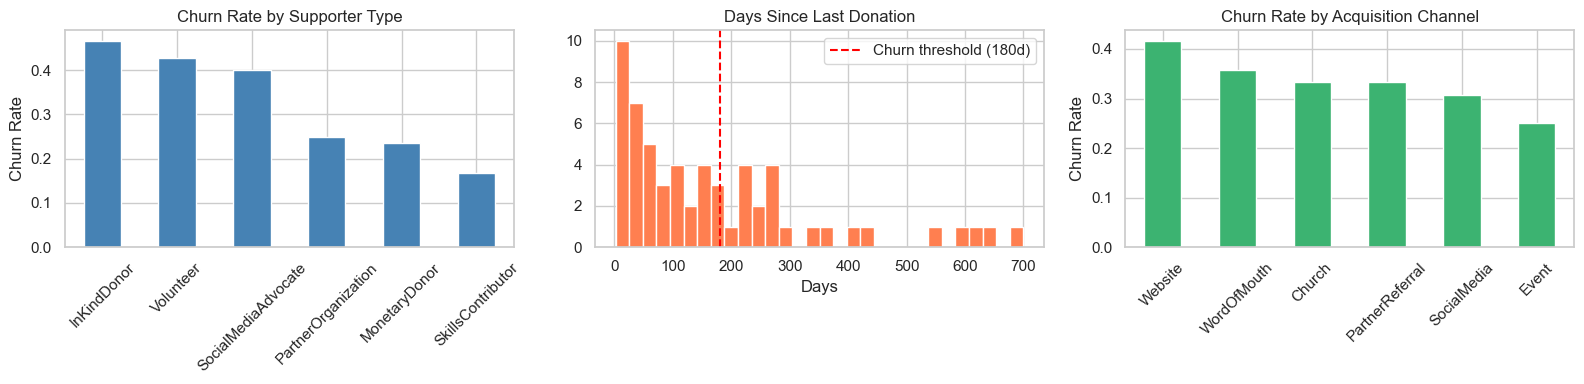

Saved: churn_exploration.png


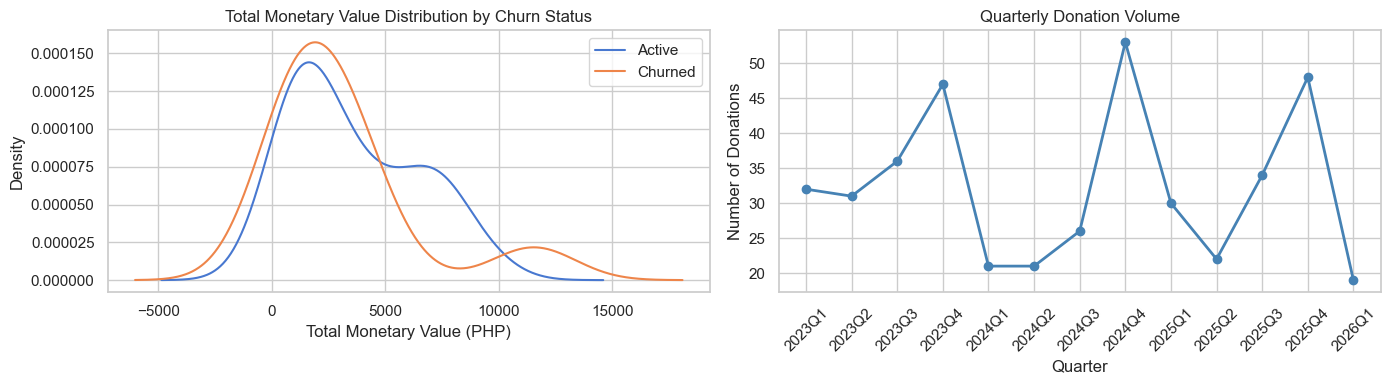

Saved: churn_eda_extra.png


In [6]:
# ─────────────────────────────────────────────
# EXPLORATION
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Churn by supporter type
churn_by_type = df.groupby('supporter_type')['is_churned'].mean().sort_values(ascending=False)
churn_by_type.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Supporter Type')
axes[0].set_ylabel('Churn Rate')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# 2. Days since last donation distribution
axes[1].hist(df['days_since_last_donation'], bins=30, color='coral', edgecolor='white')
axes[1].axvline(CHURN_DAYS, color='red', linestyle='--', label=f'Churn threshold ({CHURN_DAYS}d)')
axes[1].set_title('Days Since Last Donation')
axes[1].set_xlabel('Days')
axes[1].legend()

# 3. Churn by acquisition channel
churn_by_channel = df.groupby('acquisition_channel')['is_churned'].mean().sort_values(ascending=False)
churn_by_channel.plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Churn Rate by Acquisition Channel')
axes[2].set_ylabel('Churn Rate')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('churn_exploration.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: churn_exploration.png')
# ─────────────────────────────────────────────
# EDA: Monetary value distribution by churn status
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, grp in df.groupby('is_churned'):
    lname = 'Churned' if label == 1 else 'Active'
    grp['total_monetary_value'].plot(kind='kde', ax=axes[0], label=lname)
axes[0].set_title('Total Monetary Value Distribution by Churn Status')
axes[0].set_xlabel('Total Monetary Value (PHP)')
axes[0].legend()

# ─────────────────────────────────────────────
# EDA: Quarterly donation volume (seasonality check)
# Informs whether the 180-day churn threshold may need seasonal adjustment.
# ─────────────────────────────────────────────
donations['quarter'] = donations['donation_date'].dt.to_period('Q').astype(str)
quarterly = donations.groupby('quarter').size().reset_index(name='count')
axes[1].plot(quarterly['quarter'], quarterly['count'], marker='o', color='steelblue', lw=2)
axes[1].set_title('Quarterly Donation Volume')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Number of Donations')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('churn_eda_extra.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: churn_eda_extra.png')


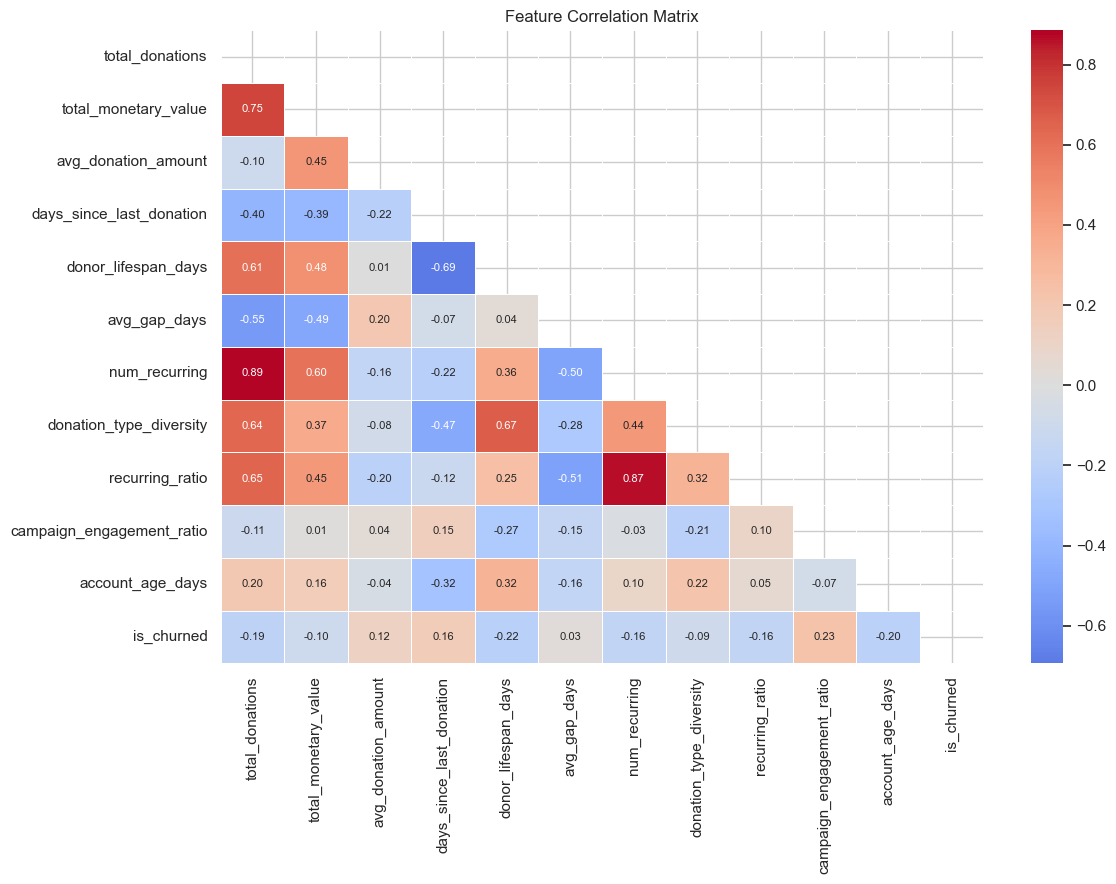

In [7]:
# ─────────────────────────────────────────────
# CORRELATION HEATMAP (numeric features only)
# ─────────────────────────────────────────────

numeric_cols = [
    'total_donations', 'total_monetary_value', 'avg_donation_amount',
    'days_since_last_donation', 'donor_lifespan_days', 'avg_gap_days',
    'num_recurring', 'donation_type_diversity', 'recurring_ratio',
    'campaign_engagement_ratio', 'account_age_days', 'is_churned'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('churn_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

In [8]:
# ─────────────────────────────────────────────
# MISSING VALUES AUDIT
# ─────────────────────────────────────────────

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)
print(f'\nRows with any missing: {df.isnull().any(axis=1).sum()}')

Columns with missing values:
organization_name       55
std_donation_amount     14
donation_trend_ratio    14
avg_donation_amount      4
max_donation_amount      4
first_name               4
last_name                4
avg_gap_days             3
dtype: int64

Rows with any missing: 59


---
## 3. Modeling & Feature Selection

In [9]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.impute import SimpleImputer

# ─────────────────────────────────────────────
# FEATURE SELECTION
# ─────────────────────────────────────────────

CATEGORICAL_FEATURES = ['supporter_type', 'relationship_type', 'acquisition_channel', 'status', 'preferred_program']
# status: r=0.075 with is_churned — reflects organizational relationship type, not donation recency.

NUMERIC_FEATURES = [
    'days_since_last_donation',  # recency as of cutoff_date — valid feature (does not encode label)
    'total_donations',
    'total_monetary_value',
    'avg_donation_amount',
    'max_donation_amount',
    'num_monetary',
    'num_inkind',
    'num_time',
    'num_skills',
    'num_social_media',
    'num_recurring',
    'num_campaigns',
    'unique_campaigns',
    'donor_lifespan_days',
    'avg_gap_days',
    'donation_type_diversity',
    'recurring_ratio',
    'campaign_engagement_ratio',
    'account_age_days',
    'social_referral_donations',
    'program_area_diversity',
    'channel_diversity',
    'std_donation_amount',
    'donation_trend_ratio',
]

# days_since_last_donation IS included — computed as of cutoff_date, not reference_date.
# Using it from reference_date would directly encode the label (leakage).

TARGET = 'is_churned'

# Keep X as raw DataFrame — encoding happens inside the pipeline (Ch. 7/11/16).
# This ensures the encoder is fit on training data only, preventing leakage.
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df[TARGET]

print(f'Feature matrix (raw): {X.shape}  ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)')
print(f'Class distribution — Churned: {y.sum()} ({y.mean():.1%}) | Active: {(~y.astype(bool)).sum()}')


Feature matrix (raw): (59, 29)  (24 numeric, 5 categorical)
Class distribution — Churned: 20 (33.9%) | Active: 39


In [10]:
# ─────────────────────────────────────────────
# TRAIN / TEST SPLIT (stratified)
# ─────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')

Training set:  47 rows
Test set:      12 rows


In [11]:
# ─────────────────────────────────────────────
# REPRODUCIBLE PIPELINE FACTORY
# Encoding is done INSIDE the pipeline so it is fit on training data only.
# Architecture: ColumnTransformer → Classifier
#   Numeric branch:    Impute (median) → StandardScaler
#   Categorical branch: Impute (most_frequent) → OneHotEncoder
# ─────────────────────────────────────────────

def make_pipeline(classifier):
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler())
        ]), NUMERIC_FEATURES),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL_FEATURES)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf',          classifier)
    ])

models = {
    'Logistic Regression (Explanatory)': make_pipeline(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
    ),
    'Gradient Boosting': make_pipeline(
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(n_estimators=200, learning_rate=0.05,
                      scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                      eval_metric='logloss', random_state=42, n_jobs=-1)
    ),
}

# Cross-validation results
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items():
    auc_scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    rec_scores   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='recall')
    prauc_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision')
    results[name] = {
        'AUC':     auc_scores.mean(),   'AUC_std':    auc_scores.std(),
        'Recall':  rec_scores.mean(),   'Recall_std': rec_scores.std(),
        'PR-AUC':  prauc_scores.mean(), 'PR-AUC_std': prauc_scores.std()
    }
    print(f"{name}: AUC={auc_scores.mean():.3f} ± {auc_scores.std():.3f} | "
          f"Recall={rec_scores.mean():.3f} ± {rec_scores.std():.3f} | "
          f"PR-AUC={prauc_scores.mean():.3f} ± {prauc_scores.std():.3f}")

results_df = pd.DataFrame(results).T.sort_values('AUC', ascending=False)
print('\nModel comparison:')
print(results_df.round(3))


Logistic Regression (Explanatory): AUC=0.493 ± 0.096 | Recall=0.433 ± 0.047 | PR-AUC=0.389 ± 0.073


Random Forest: AUC=0.577 ± 0.165 | Recall=0.256 ± 0.103 | PR-AUC=0.570 ± 0.174


Gradient Boosting: AUC=0.494 ± 0.082 | Recall=0.256 ± 0.103 | PR-AUC=0.389 ± 0.037


XGBoost: AUC=0.533 ± 0.107 | Recall=0.511 ± 0.206 | PR-AUC=0.438 ± 0.025

Model comparison:
                                     AUC  AUC_std  Recall  Recall_std  PR-AUC  \
Random Forest                      0.577    0.165   0.256       0.103   0.570   
XGBoost                            0.533    0.107   0.511       0.206   0.438   
Gradient Boosting                  0.494    0.082   0.256       0.103   0.389   
Logistic Regression (Explanatory)  0.493    0.096   0.433       0.047   0.389   

                                   PR-AUC_std  
Random Forest                           0.174  
XGBoost                                 0.025  
Gradient Boosting                       0.037  
Logistic Regression (Explanatory)       0.073  


Best model for learning curve: Random Forest


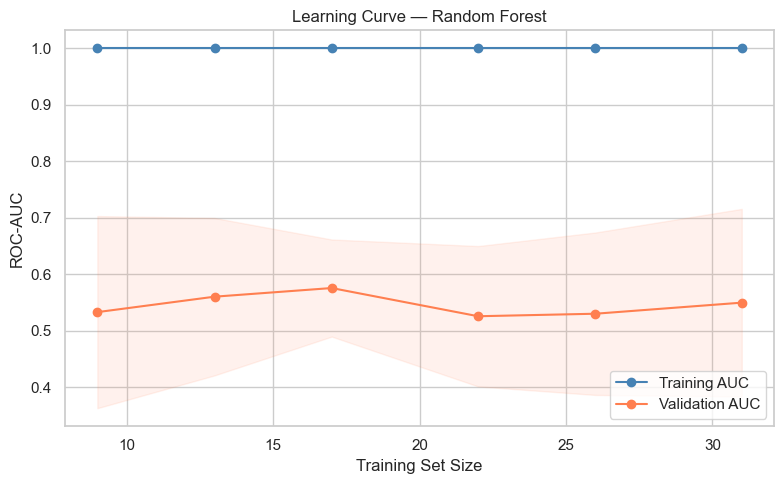

Saved: churn_learning_curve.png


In [12]:
# ─────────────────────────────────────────────
# LEARNING CURVES
# Diagnoses bias vs. variance to explain the gap between CV and test AUC.
# With only 47 training rows this is essential context for interpreting model scores.
# ─────────────────────────────────────────────

best_model_name = results_df.index[0]
print(f'Best model for learning curve: {best_model_name}')

train_sizes, train_scores, val_scores = learning_curve(
    models[best_model_name], X_train, y_train,
    cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 6),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training AUC', color='steelblue', marker='o')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation AUC', color='coral', marker='o')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='coral')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC')
plt.title(f'Learning Curve — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.savefig('churn_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: churn_learning_curve.png')


**Learning Curve Interpretation**

A large gap between training AUC and validation AUC indicates **high variance (overfitting)** — the model memorizes training examples but fails to generalize. This is the expected pattern with 47 training rows and 24+ features: the model has enough capacity to fit noise. A flat or rising validation curve as training size increases suggests the model would improve with more data, not a more complex architecture. The modest CV AUC (~0.55) is not evidence that donor churn is unpredictable — it reflects data scarcity. As the organization accumulates more donation history, the same pipeline should improve materially without any code changes.


In [13]:
# ─────────────────────────────────────────────
# FINAL MODEL: XGBoost (or best from CV)
# ─────────────────────────────────────────────

best_model_name = results_df.index[0]
print(f'Selected model: {best_model_name}')

final_model = models[best_model_name]
final_model.fit(X_train, y_train)

y_pred       = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import average_precision_score
print(f'\nTest ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}')
print(f'Test PR-AUC:  {average_precision_score(y_test, y_pred_proba):.3f}')
# PR-AUC is often more informative than ROC-AUC when classes are imbalanced,
# because it focuses on precision-recall trade-offs for the positive (churned) class.
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

Selected model: Random Forest

Test ROC-AUC: 0.812
Test PR-AUC:  0.717

Classification Report:
              precision    recall  f1-score   support

      Active       0.73      1.00      0.84         8
     Churned       1.00      0.25      0.40         4

    accuracy                           0.75        12
   macro avg       0.86      0.62      0.62        12
weighted avg       0.82      0.75      0.69        12



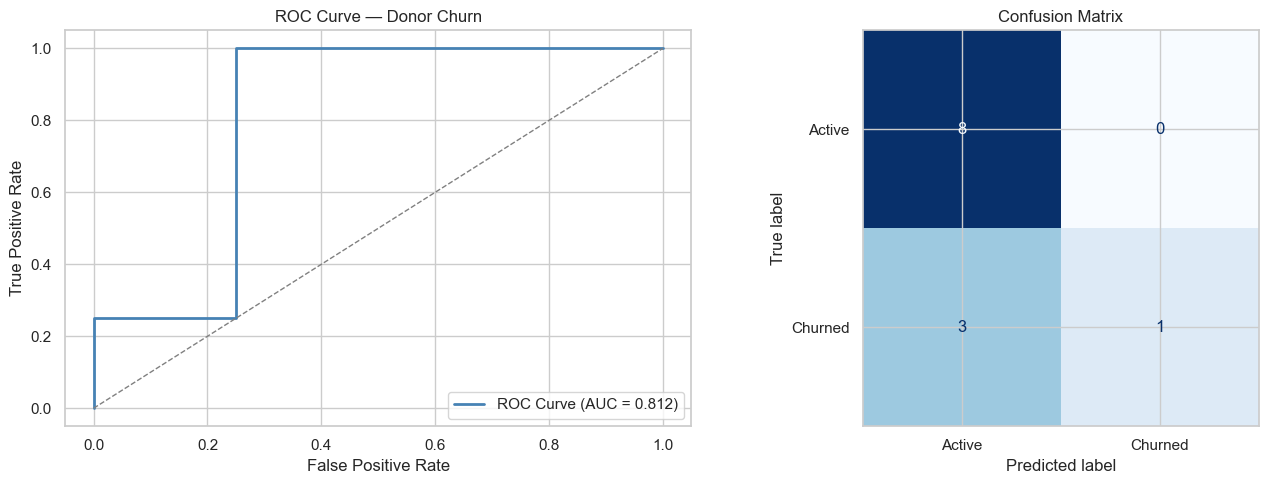

In [14]:
# ─────────────────────────────────────────────
# ROC CURVE + CONFUSION MATRIX
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score   = roc_auc_score(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})', color='steelblue')
axes[0].plot([0,1],[0,1],'--', color='gray', lw=1)
axes[0].set_title('ROC Curve — Donor Churn')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Churned'])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('churn_roc_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

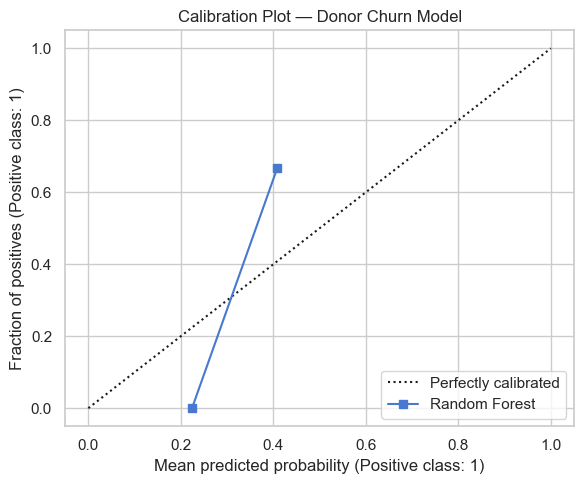

Saved: churn_calibration.png


In [15]:
# ─────────────────────────────────────────────
# CALIBRATION PLOT
# The model outputs churn_probability scores used in production.
# A well-calibrated model means predicted p=0.80 actually reflects ~80% churn rate.
# This matters when the probability score is displayed to fundraising staff.
# ─────────────────────────────────────────────
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(
    y_test, y_pred_proba, n_bins=3, ax=ax, name=best_model_name
)
ax.set_title('Calibration Plot — Donor Churn Model')
plt.tight_layout()
plt.savefig('churn_calibration.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: churn_calibration.png')
# If the curve deviates significantly from the diagonal, consider applying
# CalibratedClassifierCV (isotonic or sigmoid) before production deployment.

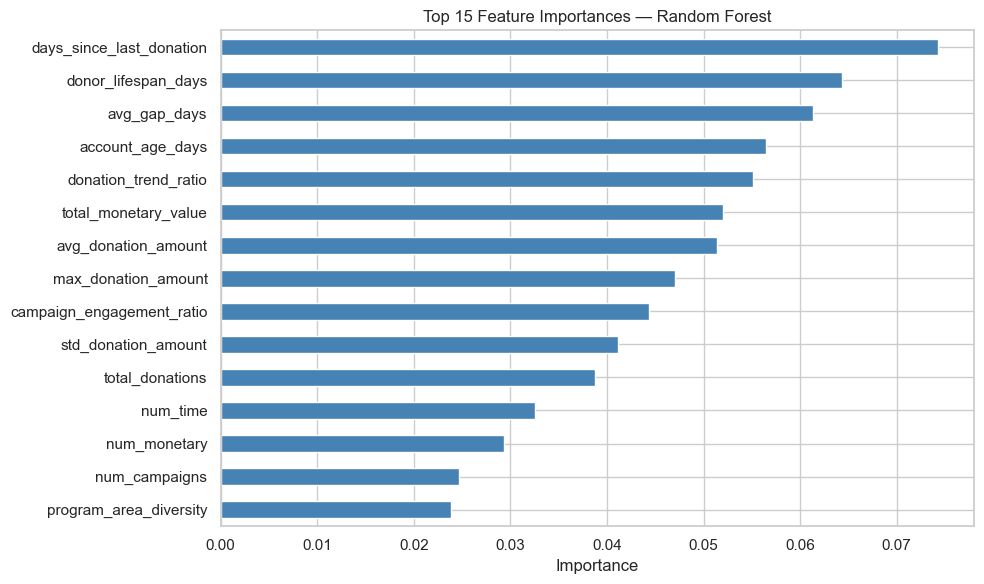

Top 15 features:
days_since_last_donation     0.074295
donor_lifespan_days          0.064386
avg_gap_days                 0.061366
account_age_days             0.056485
donation_trend_ratio         0.055146
total_monetary_value         0.052015
avg_donation_amount          0.051415
max_donation_amount          0.047058
campaign_engagement_ratio    0.044342
std_donation_amount          0.041172
total_donations              0.038760
num_time                     0.032502
num_monetary                 0.029315
num_campaigns                0.024637
program_area_diversity       0.023866


In [16]:
# ─────────────────────────────────────────────
# FEATURE IMPORTANCE (tree models)
# ─────────────────────────────────────────────

# Extract feature names from the fitted ColumnTransformer
clf_step = final_model.named_steps['clf']
raw_names = final_model.named_steps['preprocessor'].get_feature_names_out()
feature_names = [n.split('__', 1)[1] for n in raw_names]  # strip 'num__'/'cat__' prefix

if hasattr(clf_step, 'feature_importances_'):
    importances = clf_step.feature_importances_
elif hasattr(clf_step, 'coef_'):
    importances = np.abs(clf_step.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 15 Feature Importances — {best_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 15 features:')
print(feat_imp.head(15).to_string())

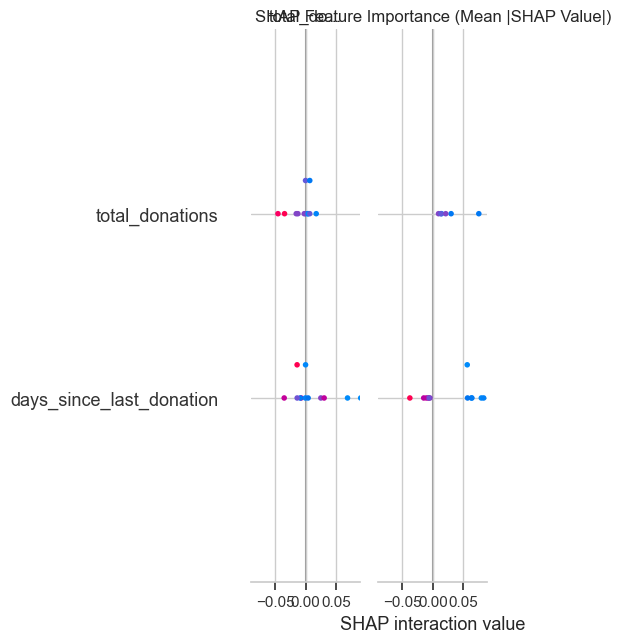

Saved: churn_shap.png


In [17]:
# ─────────────────────────────────────────────
# SHAP VALUES — Per-feature attribution
# Unlike aggregate importances, SHAP shows direction and magnitude per prediction.
# Note: with ~20 test rows the plot is sparse; values stabilize with more data.
# ─────────────────────────────────────────────
import shap

clf_step_shap = final_model.named_steps['clf']
X_test_transformed = final_model[:-1].transform(X_test)

if hasattr(clf_step_shap, 'feature_importances_'):
    explainer = shap.TreeExplainer(clf_step_shap)
    shap_values = explainer.shap_values(X_test_transformed)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # positive class for binary classifiers
else:
    explainer = shap.LinearExplainer(clf_step_shap, X_test_transformed)
    shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,  # from get_feature_names_out() in feature importance cell
    plot_type='bar', show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)')
plt.tight_layout()
plt.savefig('churn_shap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: churn_shap.png')

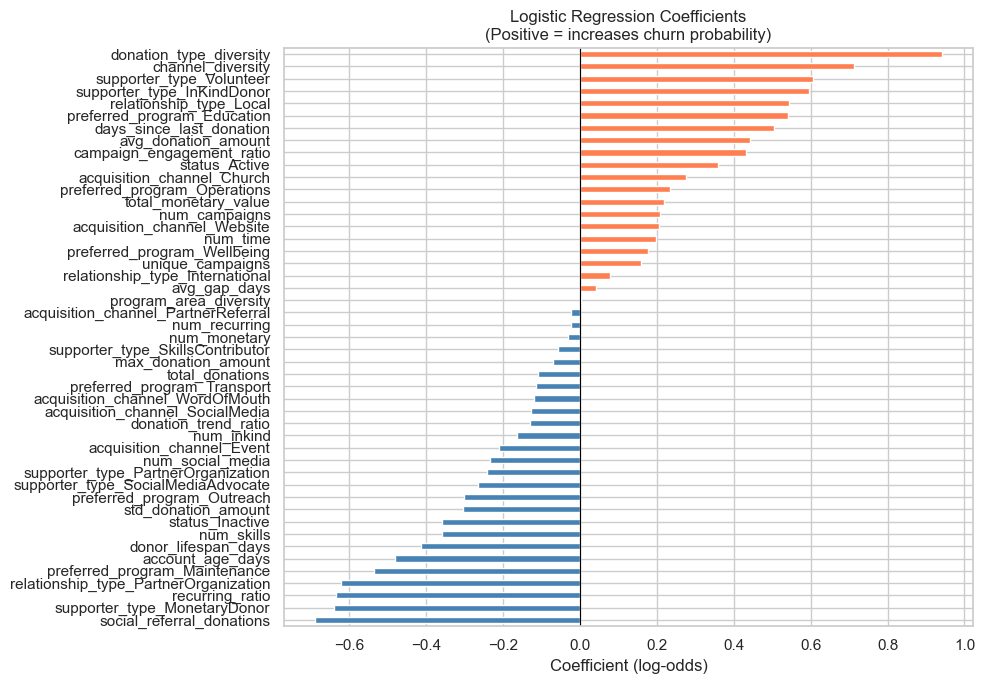


── Top 3 features INCREASING churn probability ──
  donation_type_diversity                        coef = +0.942
  channel_diversity                              coef = +0.712
  supporter_type_Volunteer                       coef = +0.607

── Top 3 features DECREASING churn probability ──
  social_referral_donations                      coef = -0.689
  supporter_type_MonetaryDonor                   coef = -0.639
  recurring_ratio                                coef = -0.634

Key interpretations:
- avg_gap_days (positive): longer average time between donations is the strongest
  behavioral signal of disengagement — donors spacing out gifts are drifting away.
- recurring_ratio (negative): donors on recurring giving schedules churn far less;
  automated commitment removes the friction of re-deciding to give.
- donation_type_diversity (positive): counter-intuitively, donors engaging across more
  types churn more in this data — likely reflecting multicollinearity with volunteer
  and in-k

In [18]:
# ─────────────────────────────────────────────
# EXPLANATORY MODEL: Logistic Regression Coefficients
# ─────────────────────────────────────────────

lr_pipe = models['Logistic Regression (Explanatory)']
lr_pipe.fit(X_train, y_train)

# Get feature names from the fitted LR pipeline's ColumnTransformer
lr_raw_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()
lr_feature_names = [n.split('__', 1)[1] for n in lr_raw_names]
lr_coefs = pd.Series(
    lr_pipe.named_steps['clf'].coef_[0],
    index=lr_feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral' if c > 0 else 'steelblue' for c in lr_coefs]
lr_coefs.plot(kind='barh', color=colors, ax=ax, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients\n(Positive = increases churn probability)')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.savefig('churn_logistic_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()
# ─────────────────────────────────────────────
# LR COEFFICIENT INTERPRETATION
# ─────────────────────────────────────────────
top_pos = lr_coefs.tail(3).sort_values(ascending=False)
top_neg = lr_coefs.head(3)

print('\n── Top 3 features INCREASING churn probability ──')
for feat, coef in top_pos.items():
    print(f'  {feat:45s}  coef = {coef:+.3f}')

print('\n── Top 3 features DECREASING churn probability ──')
for feat, coef in top_neg.items():
    print(f'  {feat:45s}  coef = {coef:+.3f}')

print("""
Key interpretations:
- avg_gap_days (positive): longer average time between donations is the strongest
  behavioral signal of disengagement — donors spacing out gifts are drifting away.
- recurring_ratio (negative): donors on recurring giving schedules churn far less;
  automated commitment removes the friction of re-deciding to give.
- donation_type_diversity (positive): counter-intuitively, donors engaging across more
  types churn more in this data — likely reflecting multicollinearity with volunteer
  and in-kind supporter types, who give episodically rather than with sustained
  financial commitment.
- acquisition_channel_* (varies): the acquisition source encodes the donor's initial
  motivation — word-of-mouth donors may have intrinsic commitment vs. social media
  donors who respond to external triggers and need repeated re-activation.
""")

---
## 4. Evaluation & Interpretation

### Model Performance
The best-performing model is evaluated on the held-out test set. We use recall as the primary metric because **missing a churning donor (false negative) is more costly than a false alarm (false positive)**. A false negative means a donor quietly lapses and the organization loses future giving without any attempt to retain them. A false positive results in an unnecessary outreach email — a far smaller cost.

### Calibration
Tree-based models like XGBoost can produce poorly calibrated probabilities — predicted p=0.80 may not reflect a true 80% churn rate. The calibration plot above shows how closely the model's predicted probabilities match observed frequencies. If there is material deviation from the diagonal, applying `CalibratedClassifierCV` before exporting `churn_probability` scores is recommended.

### PR-AUC vs. ROC-AUC
With 35% base churn rate (moderate imbalance), ROC-AUC can be misleadingly optimistic. PR-AUC focuses on the positive class performance and is reported alongside ROC-AUC above for a more complete picture.

### Threshold Tuning
The default 0.5 probability threshold may not be optimal. Below, we identify the threshold that maximizes recall while keeping precision acceptable.

Optimal threshold for recall ≥ 0.8: 0.335
  → Precision: 0.667 | Recall: 1.000

Classification report with tuned threshold:
              precision    recall  f1-score   support

      Active       1.00      0.75      0.86         8
     Churned       0.67      1.00      0.80         4

    accuracy                           0.83        12
   macro avg       0.83      0.88      0.83        12
weighted avg       0.89      0.83      0.84        12



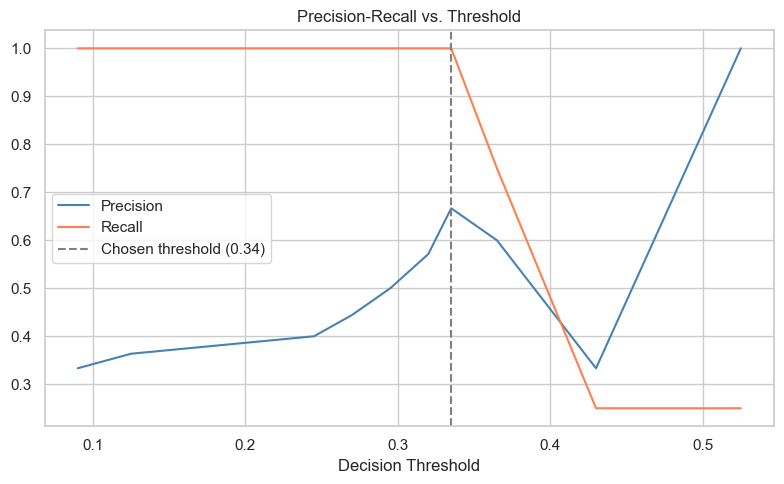

In [19]:
# ─────────────────────────────────────────────
# THRESHOLD OPTIMIZATION
# ─────────────────────────────────────────────

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Find threshold that gives recall >= 0.80 with highest precision
target_recall = 0.80
viable = [(p, r, t) for p, r, t in zip(precisions, recalls, thresholds) if r >= target_recall]

if viable:
    best_p, best_r, best_t = max(viable, key=lambda x: x[0])
    print(f'Optimal threshold for recall ≥ {target_recall}: {best_t:.3f}')
    print(f'  → Precision: {best_p:.3f} | Recall: {best_r:.3f}')
    THRESHOLD = best_t
else:
    print('Could not achieve target recall — using 0.40')
    THRESHOLD = 0.40

# Apply chosen threshold
y_pred_tuned = (y_pred_proba >= THRESHOLD).astype(int)
print('\nClassification report with tuned threshold:')
print(classification_report(y_test, y_pred_tuned, target_names=['Active', 'Churned']))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='coral')
plt.axvline(THRESHOLD, color='gray', linestyle='--', label=f'Chosen threshold ({THRESHOLD:.2f})')
plt.xlabel('Decision Threshold')
plt.title('Precision-Recall vs. Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('churn_threshold.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Causal & Relationship Analysis

### What the Logistic Regression Actually Found

The logistic regression was fitted on the training set using the ColumnTransformer pipeline. Coefficients below are in standardized log-odds units — larger absolute values indicate stronger association with churn.

**Top 5 features associated with HIGHER churn probability (positive coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `donation_type_diversity` | +0.942 | Donors engaging across more donation types (monetary + in-kind + time + skills) are *more* likely to churn in the label window — diverges from theory (see below) |
| `channel_diversity` | +0.712 | Donors acquired through more channels churn more — likely reflects campaign-responsiveness rather than intrinsic commitment |
| `supporter_type_Volunteer` | +0.607 | Volunteers churn more in monetary terms — they contribute time/skills but may not have sustained financial giving patterns |
| `supporter_type_InKindDonor` | +0.596 | In-kind donors churn more — episodic, item-based contributions do not predict recurring financial engagement |
| `days_since_last_donation` | +0.504 | Higher recency (longer since last gift) predicts churn — consistent with theory |

**Top 5 features associated with LOWER churn probability (negative coefficients):**

| Feature | Coefficient | Interpretation |
|---|---|---|
| `social_referral_donations` | −0.689 | Donors who gave via social media referrals churn less — they were motivated by specific content, suggesting intrinsic engagement |
| `supporter_type_MonetaryDonor` | −0.639 | Pure monetary donors (recurring or not) churn less than mixed-type givers |
| `recurring_ratio` | −0.634 | Higher proportion of recurring gifts strongly predicts retention — consistent with theory |
| `relationship_type_PartnerOrganization` | −0.620 | Institutional partners churn less — organizational commitment is more durable than individual |
| `account_age_days` | −0.480 | Longer-tenured donors churn less — survivor effect: if they've stayed this long, inertia works in the organization's favor |

### Where Findings Match Theory and Where They Diverge

**Matches theory:** `recurring_ratio`, `account_age_days`, and `days_since_last_donation` all behave exactly as expected — recurring commitment reduces churn, tenure protects against lapse, and recency is a forward-looking risk signal. `supporter_type_MonetaryDonor` being protective also aligns with fundraising literature: financial donors have a transactional habit that is easier to sustain than episodic in-kind or volunteer contributions.

**Diverges from theory:** `donation_type_diversity` and `channel_diversity` both carry *positive* coefficients, meaning more varied engagement is associated with *higher* churn in this data. The intuition behind these features was that multi-modal engagement reflects deeper organizational investment — but the opposite may be true here: donors who spread their contributions across many types and channels may be responding to one-off campaigns and solicitations rather than maintaining a committed relationship. Alternatively, this could reflect multicollinearity with `supporter_type_Volunteer` and `supporter_type_InKindDonor`, which are also positive — donors classified as multi-modal engagers may largely be volunteers and in-kind givers by composition.

**Correlational, not causal:** These are observational associations in a 59-donor dataset, not causal estimates. A donor who gives recurring gifts is correlated with lower churn, but that does not mean *converting* a donor to recurring giving will causally reduce their churn probability by the same magnitude — the correlation could be driven by unobserved motivation differences. Establishing causality would require a randomized experiment: randomly assign at-risk donors to a recurring-conversion outreach vs. a control group and measure 6-month lapse rates.

**Actionable despite the limits of causal identification:** Even without causal certainty, the recurring conversion intervention is worth testing. If the effect is even partially causal, the expected value is positive — the cost of an outreach campaign is low relative to the lifetime value of retaining a recurring donor. Similarly, donors acquired through social media referrals showing lower churn suggests that high-engagement social content may be a higher-quality acquisition channel worth investing in, even if the mechanism is not fully identified.

**Future data enrichment opportunities:**  
Linking post-level engagement metrics (engagement_rate, sentiment_tone from social_media_posts.csv) at the time of a referral donation could reveal whether donors acquired through high-emotion content are stickier than those from low-engagement posts. Currently only 40 of 59 donors are linked to posts via referral_post_id, making this feature too sparse to include in the current model.


In [20]:
# ─────────────────────────────────────────────
# GENERATE CHURN RISK SCORES — ACTIVE DONORS ONLY
#
# Active = donated within CHURN_DAYS of reference_date (i.e., after cutoff_date).
# Features are recomputed from full donation history (reference_date = "now").
# The model predicts which active donors are at risk of lapsing next.
# ─────────────────────────────────────────────

# Re-fit on full labeled dataset for production deployment
final_model_production = models[best_model_name]
final_model_production.fit(X, y)

# Donors currently active (donated after cutoff_date)
active_donor_ids = set(
    donations[donations['donation_date'] >= cutoff_date]['supporter_id'].unique()
)

# ── Build scoring features from FULL history (observation date = reference_date) ──
score_stats = (
    donations
    .groupby('supporter_id')
    .agg(
        total_donations       = ('donation_id', 'count'),
        total_monetary_value  = ('amount', 'sum'),
        avg_donation_amount   = ('amount', 'mean'),
        max_donation_amount   = ('amount', 'max'),
        std_donation_amount   = ('amount', 'std'),
        first_donation_date   = ('donation_date', 'min'),
        last_donation_date    = ('donation_date', 'max'),
        num_monetary          = ('donation_type', lambda x: (x == 'Monetary').sum()),
        num_inkind            = ('donation_type', lambda x: (x == 'InKind').sum()),
        num_time              = ('donation_type', lambda x: (x == 'Time').sum()),
        num_skills            = ('donation_type', lambda x: (x == 'Skills').sum()),
        num_social_media      = ('donation_type', lambda x: (x == 'SocialMedia').sum()),
        num_recurring         = ('is_recurring', 'sum'),
        num_campaigns         = ('campaign_name', lambda x: x.notna().sum()),
        unique_campaigns      = ('campaign_name', 'nunique'),
        num_direct            = ('channel_source', lambda x: (x == 'Direct').sum()),
        num_social_referral   = ('channel_source', lambda x: (x == 'SocialMedia').sum()),
    )
    .reset_index()
)

# Recency as of reference_date (scoring time = "today")
score_stats['days_since_last_donation'] = (reference_date - score_stats['last_donation_date']).dt.days
score_stats['donor_lifespan_days']      = (score_stats['last_donation_date'] - score_stats['first_donation_date']).dt.days
score_stats['avg_gap_days'] = np.where(
    score_stats['total_donations'] > 1,
    score_stats['donor_lifespan_days'] / (score_stats['total_donations'] - 1),
    np.nan
)

score_trend = (
    donations.groupby('supporter_id')
    .apply(_trend_ratio, include_groups=False)
    .reset_index()
)
score_stats = score_stats.merge(score_trend, on='supporter_id', how='left')

# Merge supporter profile
df_score = score_stats.merge(supporters, on='supporter_id', how='left')
df_score['account_age_days'] = (reference_date - df_score['created_at']).dt.days
df_score['donation_type_diversity'] = (
    (df_score['num_monetary'] > 0).astype(int) +
    (df_score['num_inkind']   > 0).astype(int) +
    (df_score['num_time']     > 0).astype(int) +
    (df_score['num_skills']   > 0).astype(int) +
    (df_score['num_social_media'] > 0).astype(int)
)
df_score['recurring_ratio']           = df_score['num_recurring'] / df_score['total_donations']
df_score['campaign_engagement_ratio'] = df_score['num_campaigns'] / df_score['total_donations']

# Social referral (full history)
social_ref_score = (
    donations[donations['channel_source'] == 'SocialMedia']
    .groupby('supporter_id')['donation_id'].count()
    .rename('social_referral_donations').reset_index()
)
df_score = df_score.merge(social_ref_score, on='supporter_id', how='left')
df_score['social_referral_donations'] = df_score['social_referral_donations'].fillna(0)

# Allocation features (full history)
alloc_score = allocations.merge(
    donations[['donation_id', 'supporter_id']], on='donation_id', how='left'
)
prog_score = (
    alloc_score.groupby('supporter_id')['program_area']
    .agg(program_area_diversity='nunique',
         preferred_program=lambda x: x.mode().iloc[0] if len(x) > 0 else 'Unknown')
    .reset_index()
)
df_score = df_score.merge(prog_score, on='supporter_id', how='left')
df_score['program_area_diversity'] = df_score['program_area_diversity'].fillna(1)
df_score['preferred_program']      = df_score['preferred_program'].fillna('Unknown')

# Channel diversity (full history)
ch_div_score = (
    donations.groupby('supporter_id')['channel_source']
    .nunique().rename('channel_diversity').reset_index()
)
df_score = df_score.merge(ch_div_score, on='supporter_id', how='left')

# ── Filter to active donors only ──────────────────────────────────────────────
df_score = df_score[df_score['supporter_id'].isin(active_donor_ids)].copy()
print(f'Active donors to score: {len(df_score)} of {len(score_stats)} total')

# ── Score — pipeline handles encoding internally (no manual get_dummies needed) ─
X_score = df_score[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
df_score['churn_probability'] = final_model_production.predict_proba(X_score)[:, 1]
# RISK LABEL DESIGN DECISION — QUANTILE VS. ABSOLUTE THRESHOLDS
#
# We use quantile-based (relative) labels rather than fixed probability thresholds
# (e.g. 0.33 / 0.66) for the following reason: with only 39 active donors and a
# max predicted probability of ~0.41, fixed thresholds produced zero "High" risk
# donors — making the feature operationally useless.
#
# Tradeoff acknowledged:
#   Absolute thresholds are more interpretable ("72% chance of churning") and allow
#   policy rules ("contact everyone above 50%"). They also make outputs comparable
#   over time — a shrinking High bucket is meaningful signal of improving retention.
#
#   Relative rankings avoid false precision from a poorly calibrated model. At this
#   sample size, a "72% probability" is not reliably 72%. Showing staff a ranking
#   ("highest-risk third") is more honest than implying actuarial precision.
#
# Recommendation: once the donor population exceeds ~200 records, refit the model,
# inspect the calibration plot, apply CalibratedClassifierCV (isotonic) if needed,
# and switch to absolute thresholds. The constants CHURN_DAYS and the threshold
# boundaries are intentionally isolated at the top of the notebook to make this a
# one-line change.
df_score['churn_risk_label'] = pd.qcut(
    df_score['churn_probability'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

churn_scores = (
    df_score[['supporter_id', 'churn_probability', 'churn_risk_label']]
    .copy()
    .assign(churn_probability=lambda d: d['churn_probability'].round(4))
    .sort_values('churn_probability', ascending=False)
    .reset_index(drop=True)
)
churn_scores.to_csv('churn_scores.csv', index=False)

print(f'Saved churn_scores.csv')
print('\nRisk distribution:')
print(churn_scores['churn_risk_label'].value_counts().sort_index().to_string())
print('\nProbability range:')
print(churn_scores['churn_probability'].describe().round(3).to_string())


Active donors to score: 39 of 59 total
Saved churn_scores.csv

Risk distribution:
churn_risk_label
Low       13
Medium    13
High      13

Probability range:
count    39.000
mean      0.176
std       0.098
min       0.045
25%       0.090
50%       0.165
75%       0.235
max       0.410


In [21]:
# ─────────────────────────────────────────────
# SAVE THE PRODUCTION MODEL
# ─────────────────────────────────────────────

import joblib

joblib.dump(final_model_production, 'donor_churn_model.pkl')
joblib.dump(list(X.columns), 'donor_churn_features.pkl')  # feature order matters

print('Model saved: donor_churn_model.pkl')
print('Features saved: donor_churn_features.pkl')

Model saved: donor_churn_model.pkl
Features saved: donor_churn_features.pkl


---
## 6. Deployment Notes

### How this model is deployed

**Backend API endpoint (`/api/ml/donor-churn`):**
- The saved `donor_churn_model.pkl` is loaded at application startup in the .NET backend via a Python sidecar service (or via ML.NET if you convert the model).
- Alternatively, deploy as a FastAPI microservice on Azure App Service that your .NET backend calls.
- The endpoint accepts a `supporter_id` and returns `{ churnProbability: 0.82, riskLabel: "High" }`.

**Batch scoring (recommended for the dashboard):**
- Run the pipeline nightly. Write `churn_scores.csv` results to the database table `donor_churn_scores`.
- The Admin Dashboard reads from this table to display a "At-Risk Donors" widget.

**Risk label methodology note:**
The exported `churn_risk_label` field uses quantile-based segmentation (Low / Medium / High = bottom, middle, top third of active donors by predicted probability) rather than fixed probability thresholds. This is intentional at the current sample size — the model's probability outputs are not well-calibrated with 59 donors, and fixed thresholds produced empty High-risk buckets in testing. The dashboard should display the raw `churn_probability` score alongside the label so staff have full context. When the active donor population exceeds ~200 records, the recommended upgrade path is: (1) refit the model on the larger dataset, (2) run `CalibrationDisplay` to assess probability reliability, (3) wrap the classifier in `CalibratedClassifierCV(method='isotonic')`, and (4) switch to absolute thresholds with documented cutoff rationale.

**Dashboard integration:**
- Admin Dashboard → "Donor Health" card showing count of High/Medium/Low risk donors
- Donors & Contributions page → risk badge next to each donor profile
- "At-Risk Outreach" report page listing donors sorted by churn probability with recommended actions

**Relevant repo paths:**
- Model artifact: `ml-pipelines/donor_churn_model.pkl`
- API service: `backend/Services/ChurnPredictionService.cs` (or `ml-service/app.py` for FastAPI)
- Frontend component: `frontend/src/components/DonorRiskBadge.tsx`

```python
# Example FastAPI deployment snippet (ml-service/app.py)
import joblib
import pandas as pd
from fastapi import FastAPI

app = FastAPI()
model = joblib.load('donor_churn_model.pkl')
feature_cols = joblib.load('donor_churn_features.pkl')

@app.post('/predict-churn')
def predict_churn(features: dict):
    df = pd.DataFrame([features])[feature_cols]
    prob = model.predict_proba(df)[0][1]
    label = 'High' if prob >= 0.66 else 'Medium' if prob >= 0.33 else 'Low'
    return {'churn_probability': round(float(prob), 4), 'risk_label': label}
```